# EGX Stock Market — Cleaning & Analysis

**Dataset:** EGX companies, daily trading records, and market indices from the Egyptian Exchange.

**Made by : Abdel-Rahman Mahmoud Atai - 202500699 , Omar Saeed Abouzeed - 202500427**
**Section 6**

In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 1. Load Data

In [54]:
df  = pd.read_csv(os.path.join('..', 'data', 'raw.csv'))
df2 = pd.read_csv(os.path.join('..', 'data', 'stock_data.csv'))

In [55]:
df.head(10)

,Company,Symbol,Date,Open,High,Low,Close,Adj Close,Volume
0,El Sewedy Electric,SWDY.CA,2025-12-01,76.010002,77.500000,76.199997,76.779999,76.779999,141509
1,El Sewedy Electric,SWDY.CA,2025-12-02,76.779999,77.300003,76.019997,76.389999,76.389999,107126
2,El Sewedy Electric,SWDY.CA,2025-12-03,76.389999,77.099998,76.300003,76.709999,76.709999,71443
3,El Sewedy Electric,SWDY.CA,2025-12-04,76.709999,77.199997,76.199997,76.199997,76.199997,90029
4,El Sewedy Electric,SWDY.CA,2025-12-07,76.199997,76.980003,75.800003,76.139999,76.139999,54092
5,El Sewedy Electric,SWDY.CA,2025-12-08,76.139999,77.000000,62.099998,65.519997,65.519997,323857
6,El Sewedy Electric,SWDY.CA,2025-12-09,65.519997,78.620003,72.000000,75.309998,75.309998,441820
7,El Sewedy Electric,SWDY.CA,2025-12-10,75.309998,76.199997,75.010002,75.260002,75.260002,172616
8,El Sewedy Electric,SWDY.CA,2025-12-11,75.260002,75.900002,75.269997,75.610001,75.610001,450109
9,El Sewedy Electric,SWDY.CA,2025-12-14,75.610001,76.000000,75.500000,75.779999,75.779999,103967


In [56]:
df2.head()

,Company,Sector,Price,1D,YTD,M.Cap,Date
0,Company,Sector,Price,1D,YTD,M.Cap,Date
1,Abu Dhabi Islamic Bank Egypt,Financials,44.30,-1.01%,+48.16%,53.16,28/04
2,Abu Qir Fertilizers,Basic Materials,90.51,+1.13%,+77.47%,114.21,28/04
3,Acrow Misr,Industrials,127.52,-,+4.64%,7.02,28/04
4,Advanced Pharmaceutical Packaging Co.,Industrials,2.33,-,-,0,28/04


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Company    1952 non-null   str    
 1   Symbol     1952 non-null   str    
 2   Date       1952 non-null   str    
 3   Open       1952 non-null   float64
 4   High       1952 non-null   float64
 5   Low        1952 non-null   float64
 6   Close      1952 non-null   float64
 7   Adj Close  1952 non-null   float64
 8   Volume     1952 non-null   int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 209.3 KB


# 2. Cleaning & Formatting

## 2.1 Dataset 1

In [58]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1952.000000,1952.000000,1952.000000,1952.000000,1952.000000,1.952000e+03
mean,33.431895,34.136418,33.016069,33.537127,32.755562,6.939729e+06
std,37.798850,38.749087,37.310041,37.991352,36.437421,1.797303e+07
min,0.670000,0.670000,0.670000,0.670000,0.625000,0.000000e+00
25%,8.137500,8.257500,8.057500,8.140000,8.140000,3.457555e+05
50%,21.295000,21.905000,21.035000,21.295000,19.740000,1.254702e+06
75%,39.787499,40.579999,39.092500,39.787499,39.522593,4.365558e+06
max,202.979996,204.979996,194.020004,202.979996,192.981476,2.189888e+08


In [59]:
df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df['Date'] = df['Date'].dt.tz_convert(None)

df.isna().sum()

Company      0
Symbol       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Company    1952 non-null   str           
 1   Symbol     1952 non-null   str           
 2   Date       1952 non-null   datetime64[us]
 3   Open       1952 non-null   float64       
 4   High       1952 non-null   float64       
 5   Low        1952 non-null   float64       
 6   Close      1952 non-null   float64       
 7   Adj Close  1952 non-null   float64       
 8   Volume     1952 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1), str(2)
memory usage: 190.3 KB


## 2.2 Dataset 2

In [61]:
df2.describe()

,Company,Sector,Price,1D,YTD,M.Cap,Date
count,290,306,306,306,301,284,284
unique,286,33,289,178,223,217,16
top,El Kahera El Watania Investment,Financials,1.00,-,-,0,28/04
freq,2,90,6,90,61,39,240


In [62]:
SECTORS = [
    'Financials', 'Basic Materials', 'Industrials', 'Consumer Goods',
    'Consumer Services', 'Technology', 'Health Care', 'Utilities', 'Telecom', 'Oil & Gas'
]

df2 = df2[df2['Sector'].isin(SECTORS)].copy()
df2 = df2.dropna(subset=['Company', 'Sector']).reset_index(drop=True)

for col in ['Price', 'M.Cap', '1D', 'YTD']:
    df2[col] = pd.to_numeric(
        df2[col].astype(str).str.replace('%','',regex=False)
                            .str.replace('+','',regex=False)
                            .str.replace(',','',regex=False)
                            .str.strip(), errors='coerce')

df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  283 non-null    str    
 1   Sector   283 non-null    str    
 2   Price    282 non-null    float64
 3   1D       193 non-null    float64
 4   YTD      221 non-null    float64
 5   M.Cap    282 non-null    float64
 6   Date     282 non-null    str    
dtypes: float64(4), str(3)
memory usage: 28.9 KB


## 2.3 Standardise Company Names & Merge

Many companies appear in both datasets under slightly different names
(e.g. `'Fawry'` vs `'Fawry for Banking Technology and Electronic Payment'`).
Without fixing this, those companies get no sector assignment after the merge.

We map every mismatched name in `df` to its counterpart in `df2`.

In [63]:
unmatched = set(df['Company'].unique()) - set(df2['Company'].unique())
print(sorted(unmatched))

['Abu Kir Fertilizers', 'Alexandria Container & Cargo Handling', 'Alexandria Mineral Oils', 'CIB Egypt', 'Cairo Poultry (Koki)', 'Commercial International Bank (CIB)', 'Egyptian Electrical Cables', 'El Sewedy Electric', 'Fawry', 'Hassan Allam Holding', 'Misr Capital', 'Modern Furniture', 'Orascom Construction', 'Orascom Telecom Media & Technology', 'Palm Hills Developments', 'Raya Holding', 'Talaat Moustafa Group', 'Unit Investments']


In [64]:
NAME_MAP = {
    'Abu Kir Fertilizers':                   'Abu Qir Fertilizers',
    'Alexandria Container & Cargo Handling': 'Alexandria Containers And Goods',
    'Alexandria Mineral Oils':               'Alexandria Mineral Oils Company',
    'Cairo Poultry (Koki)':                  'Cairo Poultry',
    'Commercial International Bank (CIB)':   'Commercial International Bank (Egypt)',
    'Egyptian Electrical Cables':            'Electro Cable Egypt Company',
    'El Sewedy Electric':                    'El Sewedy Electric Company',
    'Fawry':                                 'Fawry for Banking Technology and Electronic Payment',
    'Misr Capital':                          'Misr Financial Investments',
    'Orascom Construction':                  'Orascom Construction Industries',
    'Orascom Telecom Media & Technology':    'Global Telecom Holding',
    'Palm Hills Developments':               'Palm Hills Development Company',
    'Raya Holding':                          'Raya Holding for Financial Investments',
    'Talaat Moustafa Group':                 'TMG Holding',
}
df['Company'] = df['Company'].replace(NAME_MAP)


# 3. Processing The Data

**Formulas:**

- Range = (High − Low) / Close
- Period Return (%) = [(Close − Open) / Open] × 100
- Price vs 365-High/Low (%) = [(Close − High/Low₃₆₅) / High/Low₃₆₅] × 100
- Portfolio Value = start × ∏(1 + rₜ)
- Total Gain = Portfolio Value − start

In [65]:
df['Price_Range']   = (df['High'] - df['Low']) / df['Close']
df['Period_Return'] = ((df['Close'] - df['Open']) / df['Open']) * 100

df = df.sort_values(['Company', 'Date']).set_index('Date')

# min_periods=1 so early rows aren't dropped just because the window isn't full yet
# transform keeps the result aligned with the original index (needed for groupby)
df['High_365'] = df.groupby('Company')['High'].transform(
    lambda x: x.rolling('365D', min_periods=1).max()
)
df['Low_365'] = df.groupby('Company')['Low'].transform(
    lambda x: x.rolling('365D', min_periods=1).min()
)

df['Price_vs_365_High'] = ((df['Close'] - df['High_365']) / df['High_365']) * 100
df['Price_vs_365_Low'] = ((df['Close'] - df['Low_365']) / df['Low_365']) * 100

df = df.reset_index()

df = df.sort_values(['Company', 'Date']).reset_index(drop=True)

df['Daily_Return'] = df.groupby('Company')['Close'].pct_change()

start = 10_000
df['Portfolio_Value'] = df.groupby('Company')['Daily_Return'].transform(
    lambda r: start * (1 + r.fillna(0)).cumprod()
)
df['Total_Gain'] = df['Portfolio_Value'] - start

df

,Date,Company,Symbol,Open,High,Low,Close,Adj Close,Volume,Price_Range,Period_Return,High_365,Low_365,Price_vs_365_High,Price_vs_365_Low,Daily_Return,Portfolio_Value,Total_Gain
0,2025-12-01,Abu Qir Fertilizers,ABUK.CA,45.939999,46.180000,45.599998,45.619999,44.393658,830938,0.012714,-0.696560,46.18,45.599998,-1.212649,0.043861,NaN,10000.000000,0.000000
1,2025-12-02,Abu Qir Fertilizers,ABUK.CA,45.619999,45.840000,45.470001,45.570000,44.345001,840586,0.008119,-0.109599,46.18,45.470001,-1.320919,0.219922,-0.001096,9989.040062,-10.959938
2,2025-12-03,Abu Qir Fertilizers,ABUK.CA,45.570000,45.700001,45.180000,45.369999,44.150375,1145726,0.011461,-0.438887,46.18,45.180000,-1.754009,0.420537,-0.004389,9945.199473,-54.800527
3,2025-12-04,Abu Qir Fertilizers,ABUK.CA,45.369999,45.650002,45.299999,45.639999,44.413120,638472,0.007669,0.595108,46.18,45.180000,-1.169339,1.018148,0.005951,10004.384143,4.384143
4,2025-12-07,Abu Qir Fertilizers,ABUK.CA,45.639999,47.000000,45.650002,47.000000,45.736561,874288,0.028723,2.979844,47.00,45.180000,0.000000,4.028330,0.029798,10302.499145,302.499145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,2026-02-22,Unit Investments,UNIT.CA,10.020000,10.150000,9.790000,9.810000,9.810000,142814,0.036697,-2.095809,11.45,8.220000,-14.323139,19.343067,-0.020958,9351.764188,-648.235812
1948,2026-02-23,Unit Investments,UNIT.CA,9.810000,10.110000,9.530000,9.980000,9.980000,107709,0.058116,1.732917,11.45,8.220000,-12.838430,21.411183,0.017329,9513.822459,-486.177541
1949,2026-02-24,Unit Investments,UNIT.CA,9.980000,10.380000,9.800000,10.090000,10.090000,275812,0.057483,1.102211,11.45,8.220000,-11.877726,22.749390,0.011022,9618.684817,-381.315183
1950,2026-02-25,Unit Investments,UNIT.CA,10.090000,10.200000,9.700000,9.890000,9.890000,41144,0.050556,-1.982159,11.45,8.220000,-13.624450,20.316302,-0.019822,9428.027225,-571.972775


# 4. Visualization

In [66]:
sector_map = df2.drop_duplicates('Company').set_index('Company')['Sector'].to_dict()
df['Sector'] = df['Company'].map(sector_map)

sector_colors = {
    'Financials':        '#e74c3c',
    'Basic Materials':   "#4a2525",
    'Industrials':       '#2ecc71',
    'Consumer Goods':    '#f39c12',
    'Consumer Services': '#9b59b6',
    'Technology':        '#1abc9c',
    'Health Care':       '#e91e63',
    'Utilities':         '#00bcd4',
    'Telecom':           "#3122ff",
    'Oil & Gas':         "#080808"
}


print("Companies:", df['Company'].nunique())
print("Date range:", df['Date'].min().date(), ":", df['Date'].max().date())

Companies: 32
Date range: 2025-12-01 : 2026-02-26


---
## 4.1 Sector Network

Nodes: 28
Edges: 66


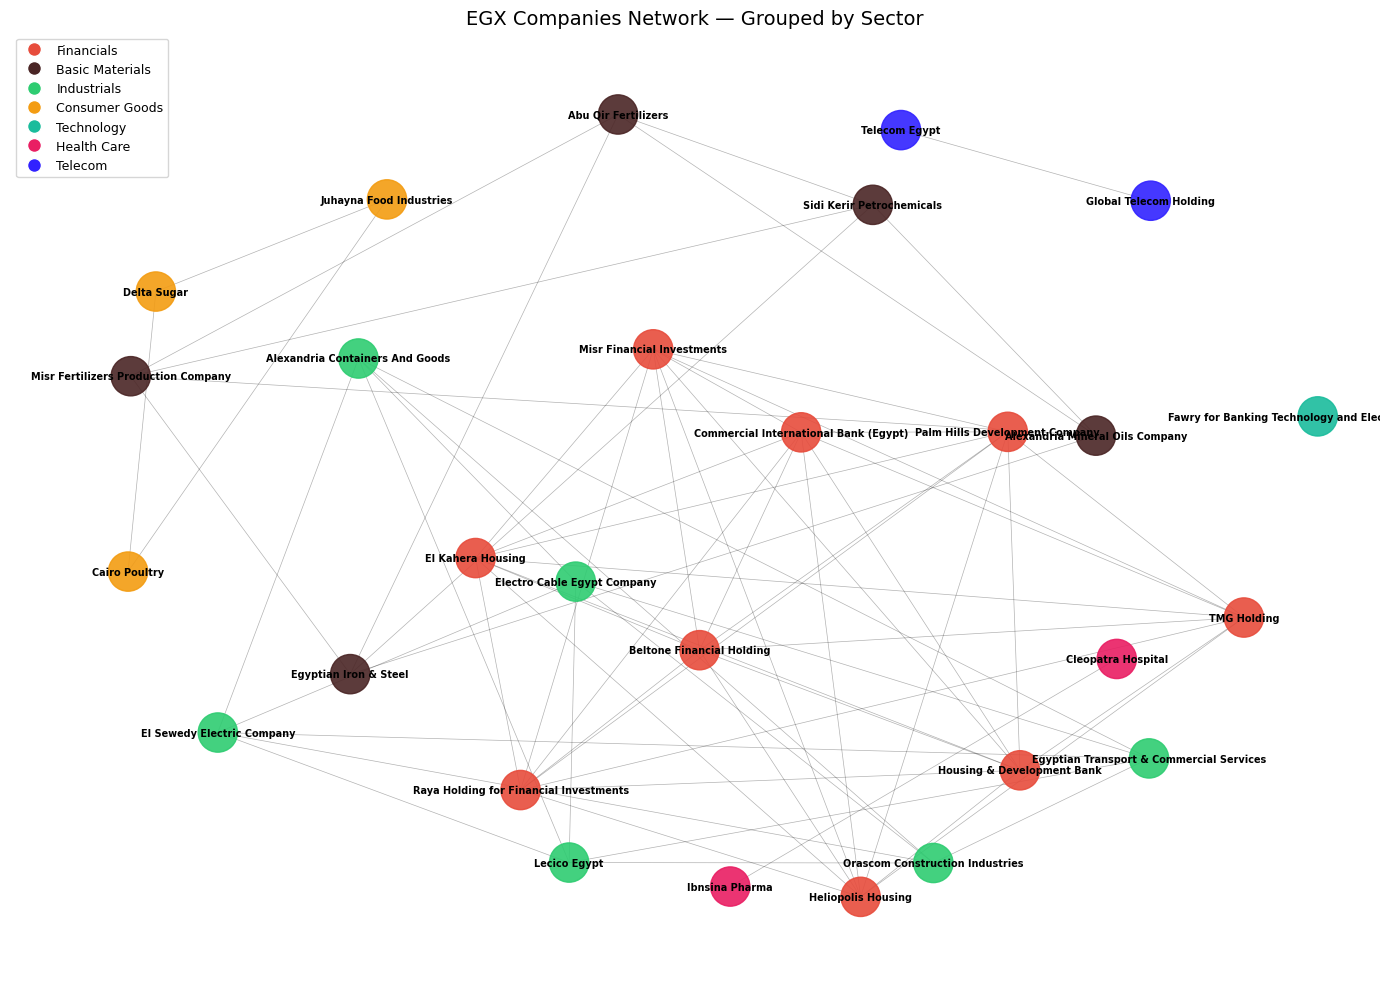

In [67]:
G_sector = nx.Graph()

sectors = df['Sector'].dropna().unique()
for sector in sectors:
    companies = df[df['Sector'] == sector]['Company'].unique()
    for company in companies:
        G_sector.add_node(company, sector=sector)
    for i in range(len(companies)):
        for j in range(i + 1, len(companies)):
            G_sector.add_edge(companies[i], companies[j])

print(f'Nodes: {G_sector.number_of_nodes()}')
print(f'Edges: {G_sector.number_of_edges()}')

node_colors = [sector_colors.get(G_sector.nodes[n].get('sector', ''), '#95a5a6') for n in G_sector.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G_sector, k=2, iterations=50, seed=42)

nx.draw_networkx_nodes(G_sector,  pos, ax=ax, node_color=node_colors, node_size=800, alpha=0.9)
nx.draw_networkx_edges(G_sector,  pos, ax=ax, edge_color='#000000', width=0.5, alpha=0.3)
nx.draw_networkx_labels(G_sector, pos, ax=ax, font_size=7, font_weight='bold')

legend_list = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=s)
    for s, c in sector_colors.items() if s in df['Sector'].dropna().unique()
]
ax.legend(handles=legend_list, loc='upper left', fontsize=9)
ax.set_title('EGX Companies Network — Grouped by Sector', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [68]:
degree_centrality = nx.degree_centrality(G_sector)

top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top nodes by degree centrality:")
print(top_degree)

Top nodes by degree centrality:
[('Beltone Financial Holding', 0.2962962962962963), ('Commercial International Bank (Egypt)', 0.2962962962962963), ('El Kahera Housing', 0.2962962962962963), ('Heliopolis Housing', 0.2962962962962963), ('Housing & Development Bank', 0.2962962962962963)]


In [69]:
betweenness_centrality = nx.betweenness_centrality(G_sector)

top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top nodes by betweenness centrality:")
print(top_betweenness)

Top nodes by betweenness centrality:
[('Abu Qir Fertilizers', 0.0), ('Alexandria Mineral Oils Company', 0.0), ('Egyptian Iron & Steel', 0.0), ('Misr Fertilizers Production Company', 0.0), ('Sidi Kerir Petrochemicals', 0.0)]


---
## 4.2  Sector Portfolio Growth

**Formula Applied:** 
    Portfolio Value = 10,000 × ∏(1 + Daily_Return)

                 Daily_Return  YTD_Return
Sector                                   
Industrials         -0.000563   19.344412
Health Care          0.001479   14.990000
Consumer Goods       0.002077    4.120000
Basic Materials      0.002138   12.188095
Technology           0.003208    8.137143
Telecom              0.003551   44.544000
Financials           0.004085    9.003151


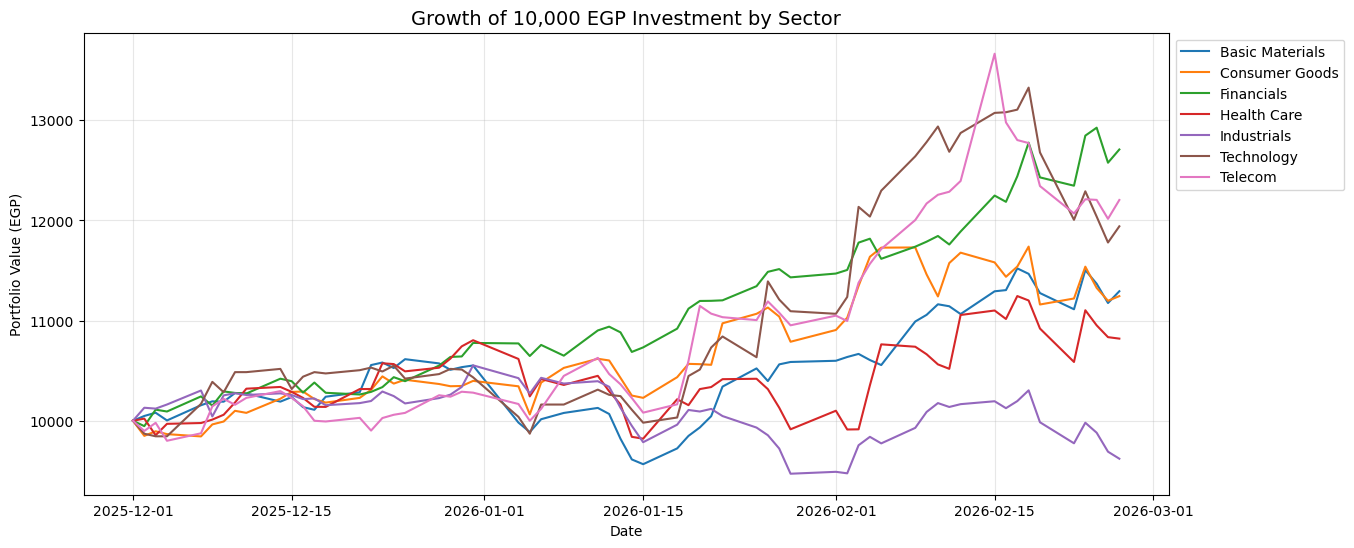

In [70]:
# Calculate average daily return and YTD by sector
sector_daily = df.groupby('Sector')['Daily_Return'].mean()
sector_ytd = df2.groupby('Sector')['YTD'].mean()

# Combine into one DataFrame
comparison = pd.DataFrame({'Daily_Return': sector_daily, 'YTD_Return': sector_ytd})

comparison = comparison.dropna().sort_values('Daily_Return')
print(comparison)

sector_stats = df.groupby('Sector').agg({ 'Daily_Return': ['mean', 'std'],'Volume': 'sum'})

sector_stats.columns = ['Avg_Daily_Return', 'Volatility', 'Total_Volume']

sector_stats = sector_stats.reset_index()

sector_mcap = df2.groupby('Sector')['M.Cap'].sum().reset_index()
sector_stats = pd.merge(sector_stats, sector_mcap, on='Sector')


sector_daily_returns = df.groupby(['Date', 'Sector'])['Daily_Return'].mean().reset_index()

sectors = sector_daily_returns['Sector'].unique()

plt.figure(figsize=(14, 6))

initial_investment = 10_000

for sector in sectors:

    # Filter data for this sector only
    sector_data = sector_daily_returns[sector_daily_returns['Sector'] == sector].copy()
    sector_data = sector_data.sort_values('Date')
    
    sector_data['Daily_Return'] = sector_data['Daily_Return'].fillna(0)
    
    
    sector_data['Cumulative'] = initial_investment * (1 + sector_data['Daily_Return']).cumprod()  
    
    
   
    plt.plot(sector_data['Date'], sector_data['Cumulative'], label=sector)

plt.title(f'Growth of {initial_investment:,} EGP Investment by Sector', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Portfolio Value (EGP)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.show()


---
## 4.3  Annualised Volatility - التقلب السنوي

Volatility measures the dispersion of daily returns. Annualising scales daily standard deviation to a yearly figure using the square-root-of-time rule:
    Ann_Volatility = Std_Daily_Return × √252

where 252 is the conventional number of trading days per year.

In [71]:
TRADING_DAYS = 252

risk = df.groupby('Company')['Daily_Return'].agg(Mean_Daily_Return='mean',Std_Daily_Return='std').dropna()

risk['Ann_Return'] = risk['Mean_Daily_Return'] * TRADING_DAYS
risk['Ann_Volatility'] = risk['Std_Daily_Return']  * np.sqrt(TRADING_DAYS)

risk = risk.reset_index()  
risk['Sector'] = risk['Company'].map(sector_map)

print(risk[['Company', 'Ann_Return', 'Ann_Volatility', 'Sector']].sort_values('Ann_Volatility', ascending=False).to_string(index=False))

                                            Company  Ann_Return  Ann_Volatility          Sector
                                      Telecom Egypt    1.773656        0.621769         Telecom
                                   Unit Investments   -0.223450        0.609141             NaN
             Raya Holding for Financial Investments    3.215781        0.594636      Financials
                         El Sewedy Electric Company    0.157503        0.491952     Industrials
                          Sidi Kerir Petrochemicals   -0.379392        0.488425 Basic Materials
                         Misr Financial Investments    1.594567        0.485159      Financials
                                      Cairo Poultry    0.782874        0.462153  Consumer Goods
                              Egyptian Iron & Steel   -0.164159        0.429012 Basic Materials
                        Electro Cable Egypt Company   -0.987861        0.427119     Industrials
                                 Heliopo

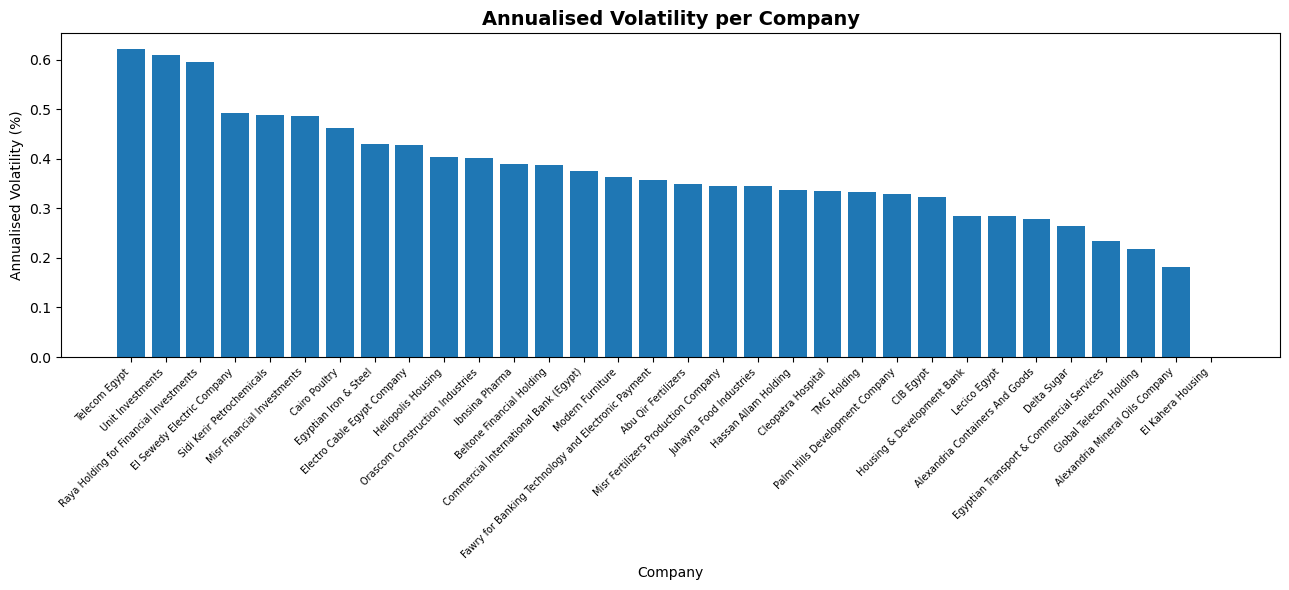

In [72]:
fig, ax = plt.subplots(figsize=(13, 6))

risk_sorted = risk.sort_values('Ann_Volatility', ascending=False)

ax.bar(risk_sorted['Company'], risk_sorted['Ann_Volatility'])

ax.set_title('Annualised Volatility per Company', fontsize=14, fontweight='bold')
ax.set_xlabel('Company')
ax.set_ylabel('Annualised Volatility (%)')

plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

---
## 4.4 Rolling 30-Day Volatility
**Formal used : Rolling Volatility (%) = std(Daily_Returns, 30-day window) × √252 × 100**

In [73]:
# Get top 5 companies by market cap
top5 = df.groupby('Company')['MarketCap'].mean().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))

for company in top5:
    # Filter data for this company
    company_data = df[df['Company'] == company].copy()
    company_data = company_data.sort_values('Date')
    company_data = company_data.set_index('Date')
    
    # Calculate 30-day rolling volatility
    rolling_vol = company_data['Daily_Return'].rolling(window=30, min_periods=5).std() 
    
    # Annualize the volatility
    rolling_vol_annual = rolling_vol * np.sqrt(TRADING_DAYS)
    
    rolling_vol_pct = rolling_vol_annual * 100
    
    ax.plot(rolling_vol_pct.index, rolling_vol_pct, label=company)
ax.set_title('30-Day Rolling Annualised Volatility — Top 5 by Market Cap',  fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Volatility (%)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

KeyError: 'Column not found: MarketCap'

New infos :

    The cumprod() method goes through the values in the DataFrame,
    from the top, row by row, 
    multiplying the values with the value from the previous row,
    ending up with a DataFrame where the last row contains the product of all values for each column.

    The rolling() method goes through the values in the DataFrame,
    row by row (or time step by time step),
    collecting a fixed-size group of consecutive values called a window,
    and then applies a calculation (such as mean(), sum(), etc.) to that window.
    The window parameter decides how many consecutive values are included in each calculation.
    The min_periods parameter decides the minimum number of valid values needed in the window before a result is returned —
    if there are fewer valid values than min_periods, the result will be NaN.

